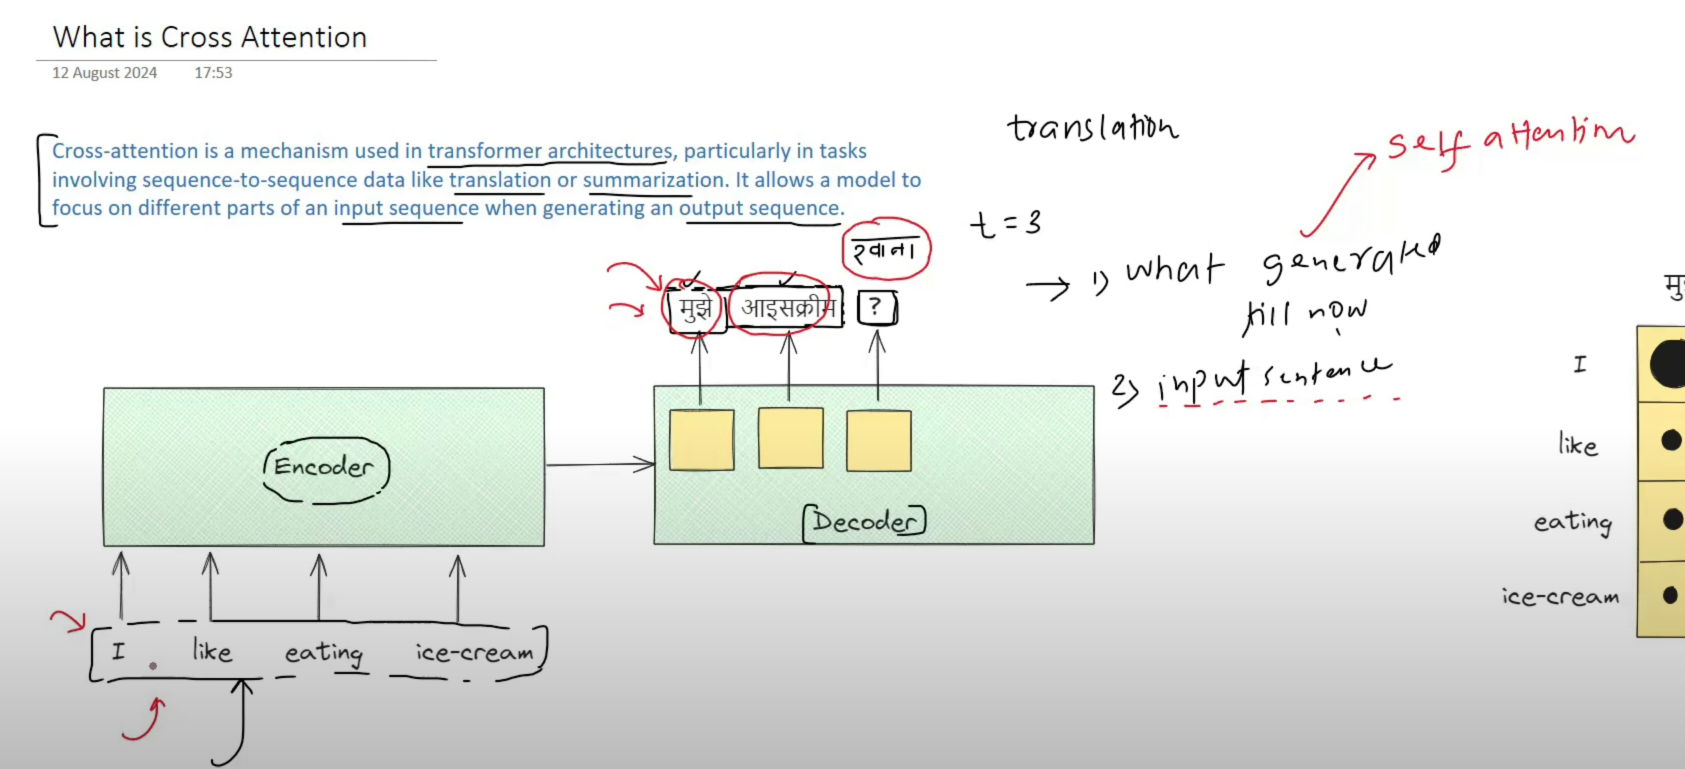

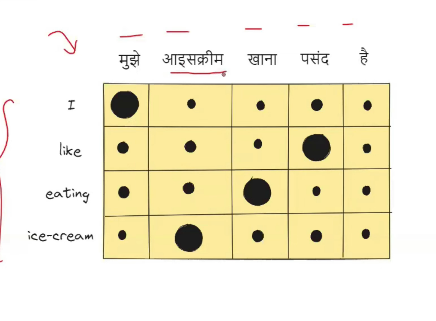

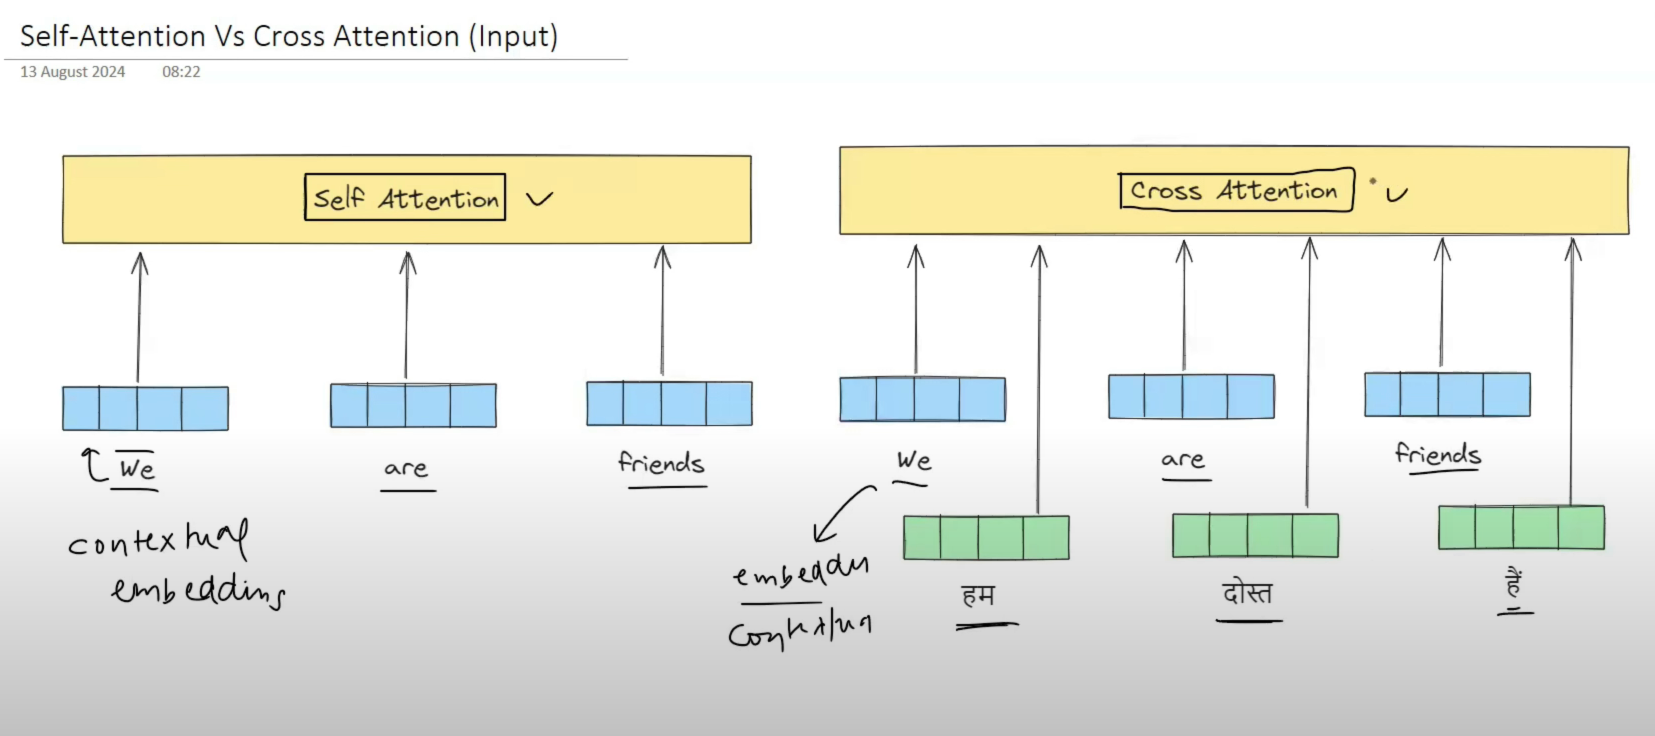

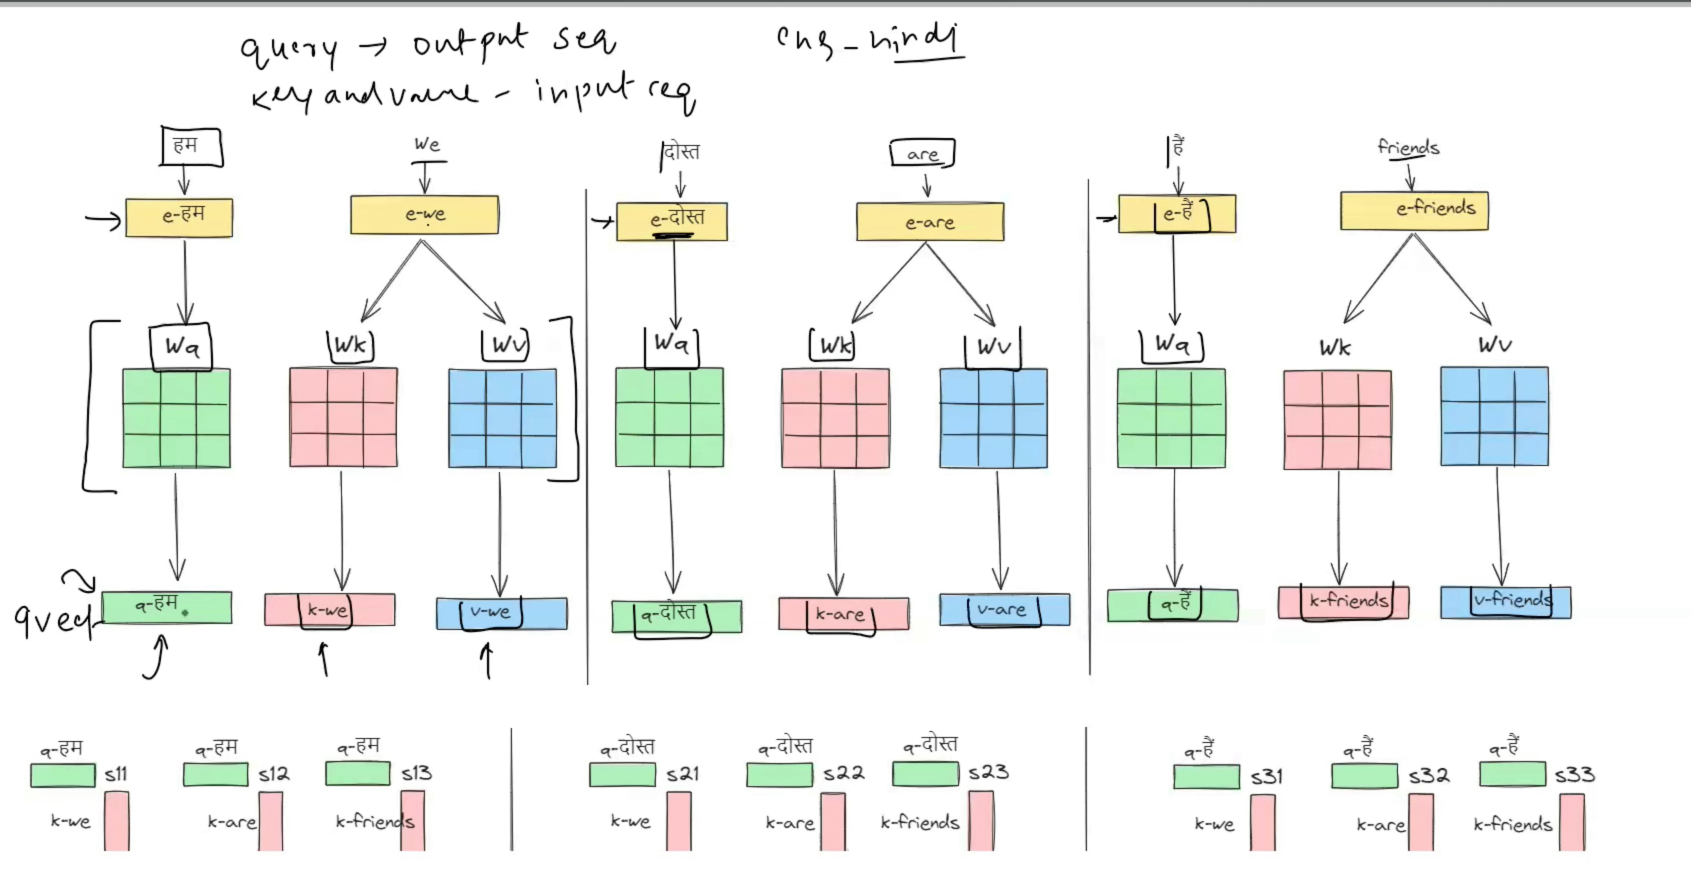

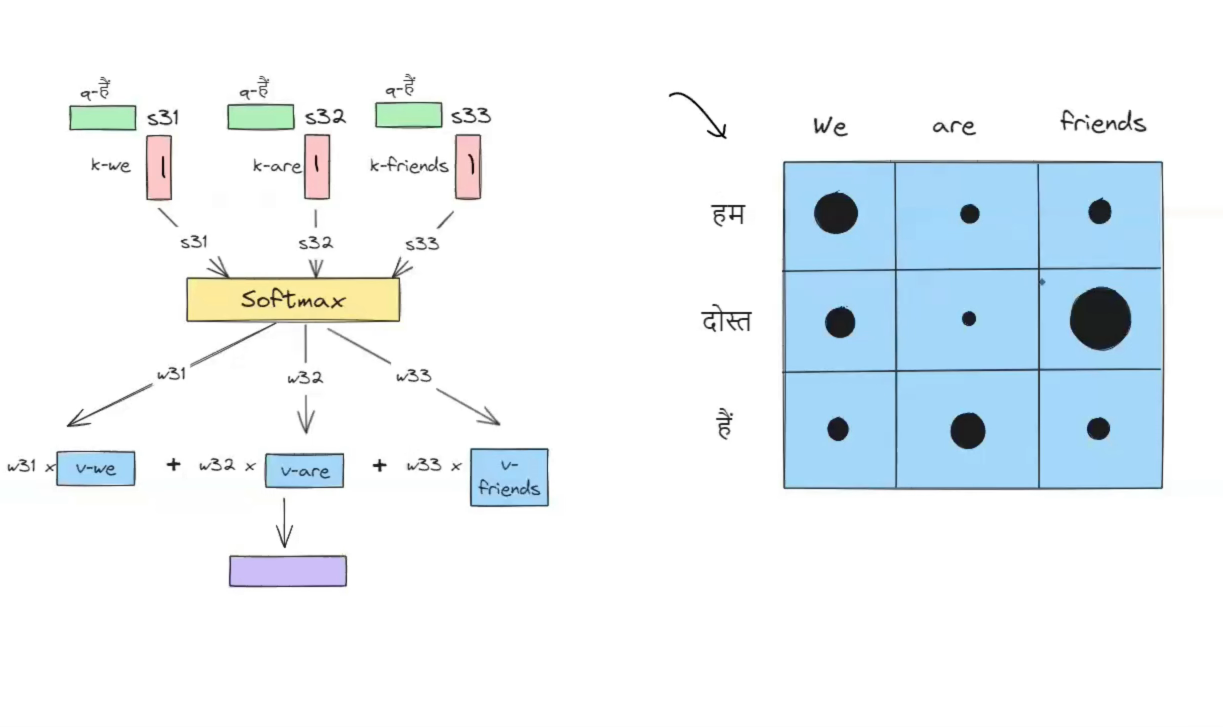

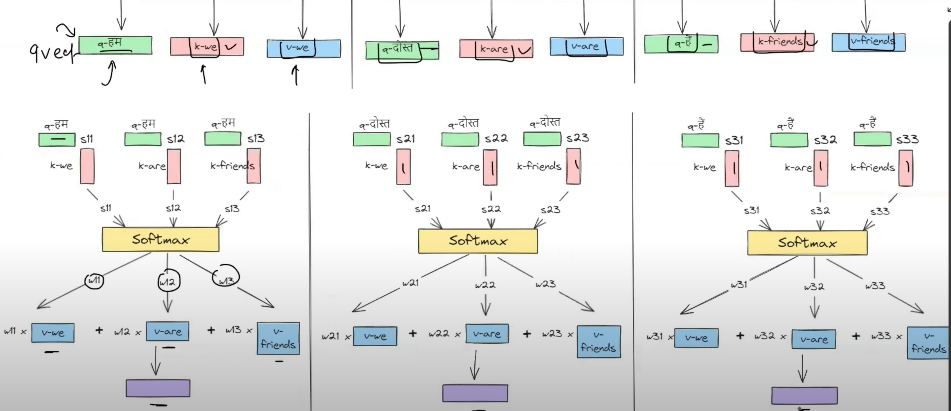

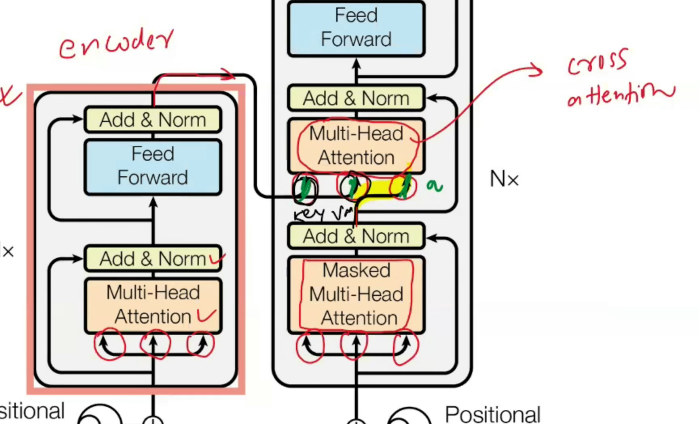

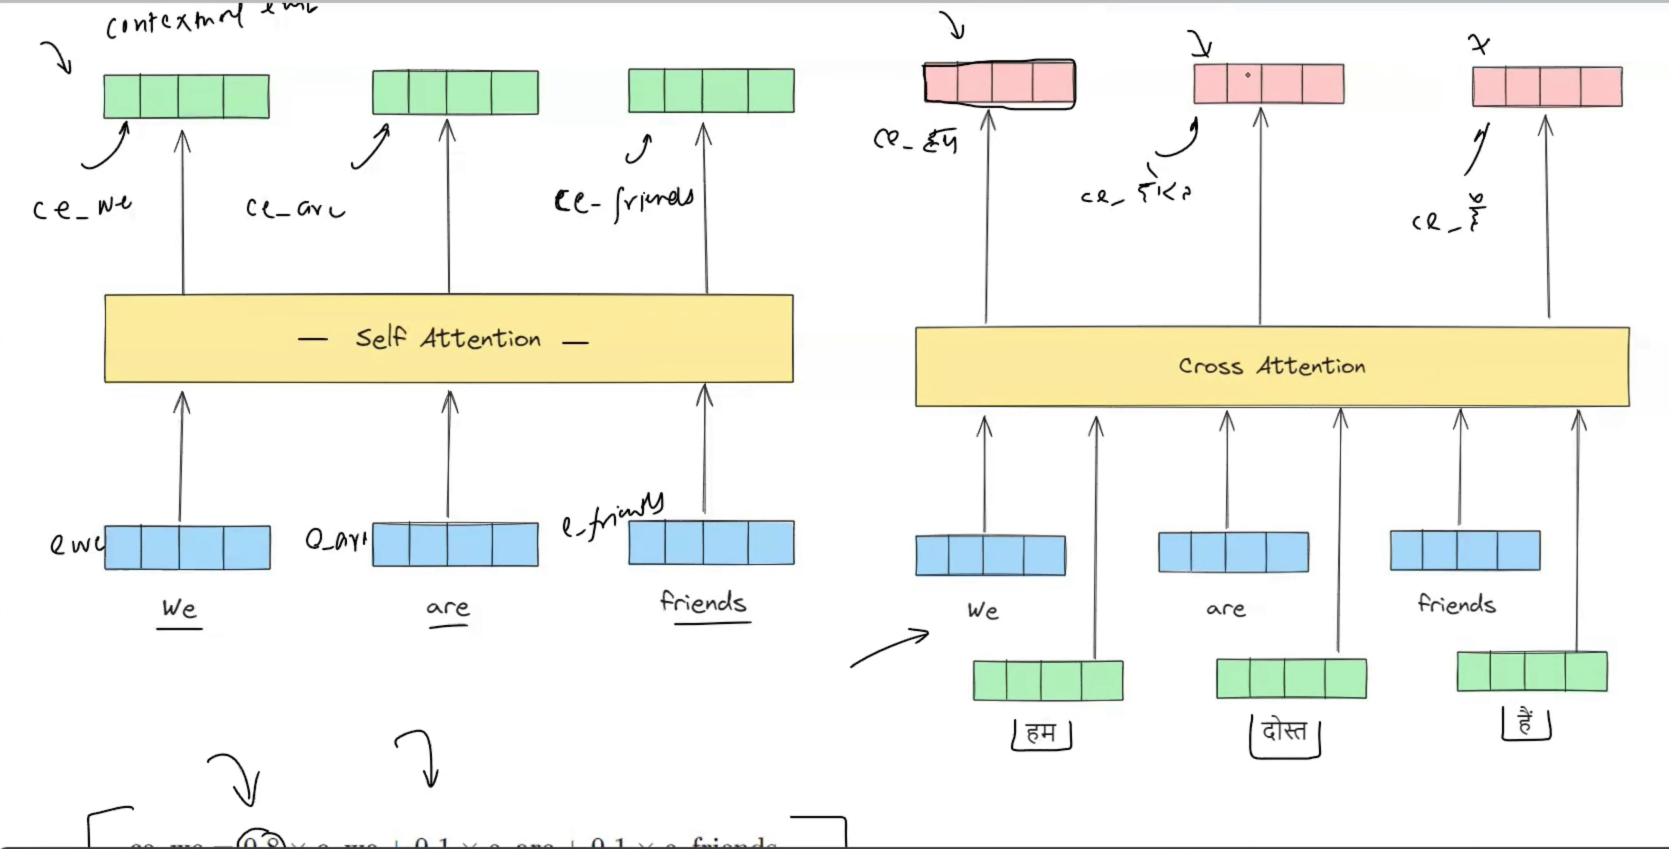

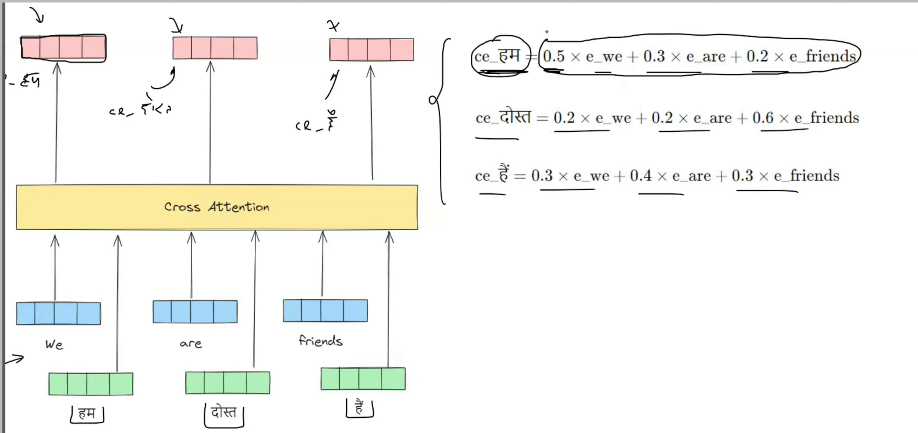

Cross-attention is a crucial mechanism within Transformer architectures, particularly for tasks involving **sequence-to-sequence data** such as machine translation or summarization. Its primary function is to allow a model to **focus on different parts of an input sequence when generating an output sequence**, thereby establishing a relationship between two distinct sequences.

### Full Summary and Steps in Cross-Attention (B2 Level)

To understand cross-attention, consider an example like translating an English sentence "I like eating ice cream" to Hindi.
1.  **The Need**: When a decoder tries to generate the next word in the Hindi translation (e.g., "खाना"), it needs to consider two things: what has been generated so far in the Hindi sentence (e.g., "मुझे आइसक्रीम") and what was written in the original English input sentence ("I like eating ice cream"). Self-attention handles the first part (context within the generated Hindi sequence), but **cross-attention addresses the second: finding the relationship between the English input and the partially generated Hindi output**. It helps the model understand, for instance, that Hindi "आइसक्रीम" strongly relates to English "ice cream".

2.  **Input**: Unlike self-attention which takes a single sequence as input, **cross-attention receives two distinct sequences**: the embeddings or contextual embeddings of the input sequence (e.g., "We are friends" in English) and the embeddings or contextual embeddings of the output sequence (e.g., "हम दोस्त हैं" in Hindi).

3.  **Query, Key, and Value Generation**: This is where a major difference lies.
    *   **Query (Q) vectors are generated *only* from the output sequence** (e.g., the Hindi words). For each word in the output sequence (e.g., "हम", "दोस्त", "हैं"), its embedding is multiplied by a weight matrix (Wq) to produce a query vector.
    *   **Key (K) and Value (V) vectors are generated *only* from the input sequence** (e.g., the English words). For each word in the input sequence (e.g., "We", "are", "friends"), its embedding is multiplied by separate weight matrices (Wk and Wv) to produce a key vector and a value vector, respectively.

4.  **Calculating Attention Scores**:
    *   Each Query vector (from the output sequence) is **dot-producted with *every* Key vector** (from the input sequence). This calculation determines the similarity or relevance between each word in the output sequence and every word in the input sequence.
    *   These similarity scores are then typically scaled and passed through a softmax function to get **attention weights**. These weights indicate how much focus each output word should place on each input word. For instance, it might show that the Hindi word "हम" is very similar to the English word "We".

5.  **Generating Contextual Embeddings**:
    *   Finally, these attention weights are used to compute a **weighted sum of the Value vectors** (from the input sequence).
    *   The result is a set of **contextual embeddings for the *output sequence***. The number of these output contextual embeddings will be exactly the same as the number of words in the output sequence. Each contextual embedding for an output word encapsulates information from relevant input words, guided by the attention weights. For example, the contextual embedding for "हम" might be 50% from "V", 30% from "आर", and 20% from "फ्रेंड्स".

### Similarities and Differences with Self-Attention

**Similarities**:
*   **Conceptual Foundation**: Cross-attention is **conceptually very similar to self-attention**. Both mechanisms aim to calculate relationships and derive contextual information.
*   **Core Mechanism**: Both utilize the fundamental "Query-Key-Value" model, where input embeddings are transformed into Q, K, and V vectors, attention scores are calculated using dot products, and these scores are used as weights to sum the Value vectors.
*   **Weight Matrices**: Both use learnable weight matrices (Wq, Wk, Wv) to transform embeddings into Q, K, and V vectors.
*   **Mathematical Operations**: Both involve dot products, scaling, softmax, and weighted sums to produce the final contextual embeddings.

**Differences**:
*   **Input Sequence Source**:
    *   **Self-attention**: Takes a **single sequence** (e.g., "We are friends") as its input.
    *   **Cross-attention**: Takes **two distinct sequences** (e.g., "We are friends" and "हम दोस्त हैं") as its input.
*   **Source of Query, Key, and Value Vectors**:
    *   **Self-attention**: All three vectors (Q, K, V) are derived **from the *same* input sequence**.
    *   **Cross-attention**: **Queries (Q) come from the *output sequence*** (e.g., the partially generated translation), while **Keys (K) and Values (V) come from the *input sequence*** (e.g., the original sentence). This is the most significant processing difference.
*   **Purpose/Focus**:
    *   **Self-attention**: Calculates how words within the **same sequence** relate to each other to build context within that sequence.
    *   **Cross-attention**: Calculates the relationship between words in **two *different* sequences**, enabling the model to focus on relevant parts of one sequence while processing another.
*   **Output**:
    *   **Self-attention**: Produces contextual embeddings for **each word of the *single input sequence***, enriching its representation based on other words in the same sequence.
    *   **Cross-attention**: Produces contextual embeddings for the **words of the *output sequence***, where each output word's embedding is contextually informed by the words in the input sequence. The number of output vectors matches the number of words in the output sequence.

### How it Works

Cross-attention essentially acts as a bridge, allowing information to flow from one sequence (the source) to another (the target). In machine translation, the decoder uses cross-attention to look back at the original English sentence (the input sequence) to decide what word to generate next in the Hindi translation (the output sequence).

The "query" comes from the word currently being generated in the target language (Hindi). This query is then compared against all the "keys" from the source language sentence (English). This comparison gives a similarity score, or "attention weight," indicating how relevant each English word is to the current Hindi word being formed. These weights are then used to combine the "values" from the English words, creating a rich "contextual embedding" for the Hindi word that incorporates relevant information from the English sentence. This mechanism ensures that the generated output is not only grammatically sound within itself but also semantically aligned with the input.

Cross-attention is a very important concept in deep learning and is widely used in areas like machine translation, question answering, image captioning (where an image is input and text is output), text-to-image generation, and text-to-speech systems, especially in the development of Large Language Models (LLMs) and Generative AI.


---

## 🔹 1. Refresher: Self-Attention

Self-attention is a mechanism where **queries (Q), keys (K), and values (V)** all come from the *same sequence*.

* Example: In a sentence `"The cat sat on the mat"`, each word attends to all other words in the same sentence.
* This helps tokens understand their context.

**Formula (scaled dot-product attention):**

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

where:

* $Q = XW^Q$, $K = XW^K$, $V = XW^V$
* $X$ = input sequence embedding.
* $d_k$ = key dimension (scaling factor).

---

## 🔹 2. Cross-Attention

Cross-attention is similar, but **queries come from one sequence** while **keys and values come from another sequence**.

* This is used in **encoder-decoder models** (like in machine translation):

  * Decoder generates queries.
  * Encoder output provides keys and values.
* Intuition: The decoder "looks up" relevant information from the encoder’s representation to produce the next token.

**Formula (same as self-attention, but inputs differ):**

$$
\text{CrossAttention}(Q_{\text{dec}}, K_{\text{enc}}, V_{\text{enc}}) = \text{softmax}\!\left(\frac{Q_{\text{dec}} K_{\text{enc}}^\top}{\sqrt{d_k}}\right) V_{\text{enc}}
$$

---

## 🔹 3. Step-by-Step Calculation (Cross-Attention)

Let’s imagine:

* Encoder outputs sequence $E \in \mathbb{R}^{n \times d}$ (length $n$)
* Decoder hidden state sequence $D \in \mathbb{R}^{m \times d}$ (length $m$)

Steps:

1. **Form projections**

   * $Q = DW^Q$ (decoder queries)
   * $K = EW^K$, $V = EW^V$ (encoder keys/values)

2. **Similarity scores**

   * Compute dot-products: $S = QK^\top$ (size $m \times n$)

3. **Scale and normalize**

   * $A = \text{softmax}(S / \sqrt{d_k})$
   * Each row = attention distribution over encoder tokens for one decoder token.

4. **Weighted sum**

   * Output = $A V$ (size $m \times d_v$)
   * Each decoder position gets context from encoder sequence.

---

## 🔹 4. Intuition

* **Self-attention**: Each token asks, *“Which other tokens in my sequence are relevant to me?”*
* **Cross-attention**: Each decoder token asks, *“Which parts of the encoder’s sequence should I look at to produce my output?”*

---

## 🔹 5. Key Similarities & Differences

| Feature             | Self-Attention                  | Cross-Attention                       |
| ------------------- | ------------------------------- | ------------------------------------- |
| Queries (Q)         | From same sequence as K, V      | From a different sequence (decoder)   |
| Keys & Values (K,V) | Same sequence (encoder/decoder) | From another sequence (encoder)       |
| Usage               | Context within same sequence    | Align/condition on another sequence   |
| Example             | Understanding word dependencies | Translation: decoder looks at encoder |

---

✅ **Summary:**

* Both use the same math, but differ in **where Q, K, V come from**.
* Self-attention = "intra-sequence reasoning."
* Cross-attention = "inter-sequence reasoning."

---






---

# 🔹 Full Transformer Pipeline with Cross-Attention

We’ll use your translation example:
**English input (encoder):** *“I like eating ice cream”*
**Hindi output (decoder so far):** *“मुझे आइसक्रीम …”*

Goal → predict next word (*“खाना”*).

---

## Step 1. Encoder Processing (source sentence)

1. **Input embeddings**: each English token (“I”, “like”, …) is mapped to a vector.
   Example (toy 4-dim embeddings):

   ```
   "I"       → [1.0, 0.0, 0.0, 0.0]
   "like"    → [0.0, 1.0, 0.0, 0.0]
   "eating"  → [0.0, 0.0, 1.0, 0.0]
   "ice"     → [0.0, 0.0, 0.0, 1.0]
   "cream"   → [0.5, 0.5, 0.0, 0.0]
   ```

2. **Positional encoding** is added so order matters.

3. **Self-attention layers (inside encoder)**: Each word attends to all others → produces **contextualized embeddings** (still one vector per word, but enriched with global context).

   Let’s call these final encoder outputs:

   $$
   E = [h_{\text{I}}, h_{\text{like}}, h_{\text{eating}}, h_{\text{ice}}, h_{\text{cream}}]
   $$

These $h$ vectors are **frozen** after the encoder is done and sent to the decoder.

---

## Step 2. Decoder Processing (target sentence so far)

At each decoding step, the decoder layer does 3 things:

1. **Masked self-attention** → makes sure each Hindi word only sees earlier words (e.g., “मुझे” and “आइसक्रीम” cannot peek at future tokens).
2. **Cross-attention** → uses encoder outputs (E) to fetch relevant source info.
3. **Feedforward** → transforms and passes to next decoder layer.

---

## Step 3. Cross-Attention in Action (decoder step)

Let’s zoom in on **cross-attention** when predicting *“खाना”*:

1. **Decoder state (query Q)**:
   The decoder has already produced hidden states for *“मुझे आइसक्रीम”*.
   When it prepares to generate the next word, it produces a hidden state vector $d_t$.
   This becomes the **query Q**:

   $$
   Q = d_t W^Q
   $$

   Example (toy numbers):

   ```
   Q = [0.0, 0.0, 1.0, 0.2]
   ```

   (high in the 3rd dimension → wants to focus on “eating”).

---

2. **Encoder outputs → Keys & Values**:
   From the encoder outputs $E$:

   $$
   K = E W^K, \quad V = E W^V
   $$

   So each English token provides a **key** (for similarity check) and a **value** (info to pass).

---

3. **Attention scores (similarity between Q & K)**:
   Compute dot product of Q with every key:

   ```
   [I, like, eating, ice, cream]
   Scores = [0.0, 0.0, 1.0, 0.2, 0.0]
   ```

   → “eating” gets the strongest score.

---

4. **Scale & softmax → attention weights**:

   ```
   Softmax(scores) = [0.17, 0.17, 0.29, 0.19, 0.17]
   ```

   → Decoder assigns \~29% focus to “eating”, \~19% to “ice”, smaller weights elsewhere.

---

5. **Weighted sum of values (context vector)**:

   ```
   Context = Σ (weight_i × value_i)
           = 0.26*h_I + 0.26*h_like + 0.29*h_eating + 0.19*h_ice + 0.17*h_cream
   ```

   So the decoder builds a **context vector** that encodes:
   “mostly about eating, some about ice/cream, little about others.”

---

6. **Residual connection + normalization**:
   The context is **added back** to the decoder state and normalized:

   $$
   d'_t = \text{LayerNorm}(d_t + \text{Context})
   $$

---

7. **Feedforward + output softmax**:

   * Pass $d'_t$ through a feedforward network.
   * Final linear + softmax layer produces probabilities over vocabulary.
   * Highest probability → *“खाना”*.

---

# 🔹 Key Takeaway

* The **encoder** prepares a rich representation of the entire source sentence.
* The **decoder** uses **cross-attention** at each step to ask:
  *“Which parts of the source are relevant to the next word I’m generating?”*
* This dynamic lookup ensures correct **alignment** (e.g., “खाना” ↔ “eating”).

---

